# SF/Fantasy Genre Trend Analysis, 2017–2025

Using the most reliable years: 2017+ has near-zero SF/Fantasy undifferentiated entries, and description-based genre inference is available throughout.

In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv('books_20260313_211555_normalized.csv')

# Combined genre: use genre_bucket where labeled, genre_inferred to fill gaps
df['genre_combined'] = df['genre_bucket'].where(df['genre_bucket'] != 'Unknown', df['genre_inferred'])

# Filter to 2017–2025 (complete years, reliable data)
df17 = df[df['year'].between(2017, 2025)].copy()

print(f"Rows in 2017–2025: {len(df17)}")
print(df17['genre_combined'].value_counts())

Rows in 2017–2025: 6820
genre_combined
Fantasy        2232
SF             1663
YA              986
Other           819
Horror          796
SF/Fantasy      138
Non-fiction     100
Unknown          86
Name: count, dtype: int64


In [2]:
# Year-by-year counts for the main genres
main_genres = ['SF', 'Fantasy', 'Horror', 'YA']

counts = (
    df17[df17['genre_combined'].isin(main_genres)]
    .groupby(['year', 'genre_combined'])
    .size()
    .reset_index(name='count')
)

counts

,year,genre_combined,count
0,2017.0,Fantasy,239
1,2017.0,Horror,31
2,2017.0,SF,218
3,2017.0,YA,82
4,2018.0,Fantasy,216
5,2018.0,Horror,32
6,2018.0,SF,211
7,2018.0,YA,65
8,2019.0,Fantasy,247
9,2019.0,Horror,33


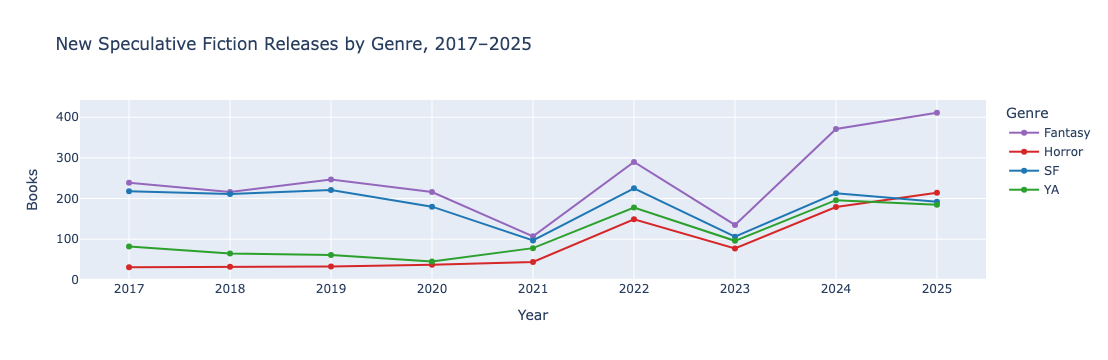

In [3]:
# --- Chart 1: Absolute counts by genre ---
fig = px.line(
    counts,
    x='year', y='count', color='genre_combined',
    markers=True,
    title='New Speculative Fiction Releases by Genre, 2017–2025',
    labels={'year': 'Year', 'count': 'Books', 'genre_combined': 'Genre'},
    color_discrete_map={
        'SF': '#1f77b4',
        'Fantasy': '#9467bd',
        'Horror': '#d62728',
        'YA': '#2ca02c',
    }
)
fig.update_layout(xaxis=dict(tickmode='linear', dtick=1))
fig.show()

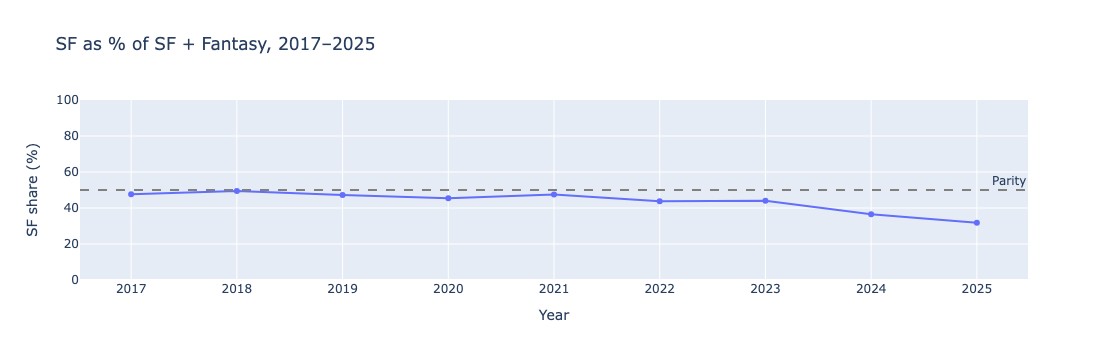

In [4]:
# --- Chart 2: SF as % of SF + Fantasy ---
pivot = counts.pivot(index='year', columns='genre_combined', values='count').fillna(0)
pivot['SF_pct'] = pivot['SF'] / (pivot['SF'] + pivot['Fantasy']) * 100

fig2 = px.line(
    pivot.reset_index(),
    x='year', y='SF_pct',
    markers=True,
    title='SF as % of SF + Fantasy, 2017–2025',
    labels={'year': 'Year', 'SF_pct': 'SF share (%)'},
)
fig2.add_hline(y=50, line_dash='dash', line_color='gray', annotation_text='Parity')
fig2.update_layout(xaxis=dict(tickmode='linear', dtick=1), yaxis=dict(range=[0, 100]))
fig2.show()

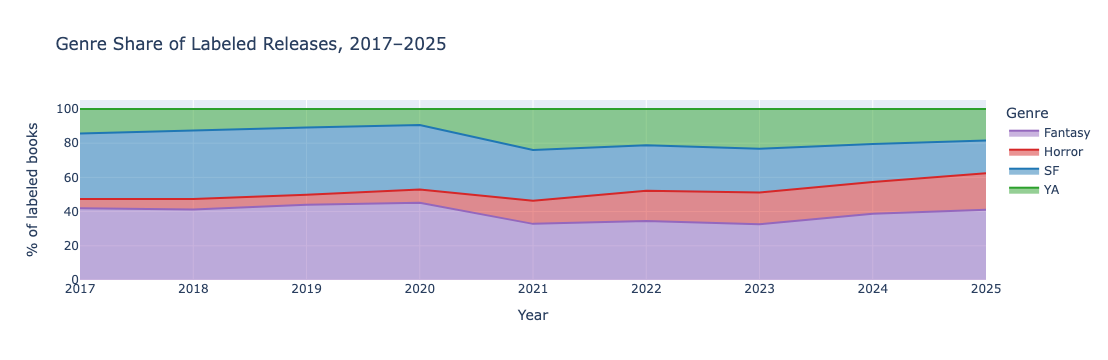

In [5]:
# --- Chart 3: Stacked area — share of total labeled books ---
total_per_year = counts.groupby('year')['count'].transform('sum')
counts['share'] = counts['count'] / total_per_year * 100

fig3 = px.area(
    counts,
    x='year', y='share', color='genre_combined',
    title='Genre Share of Labeled Releases, 2017–2025',
    labels={'year': 'Year', 'share': '% of labeled books', 'genre_combined': 'Genre'},
    color_discrete_map={
        'SF': '#1f77b4',
        'Fantasy': '#9467bd',
        'Horror': '#d62728',
        'YA': '#2ca02c',
    }
)
fig3.update_layout(xaxis=dict(tickmode='linear', dtick=1))
fig3.show()

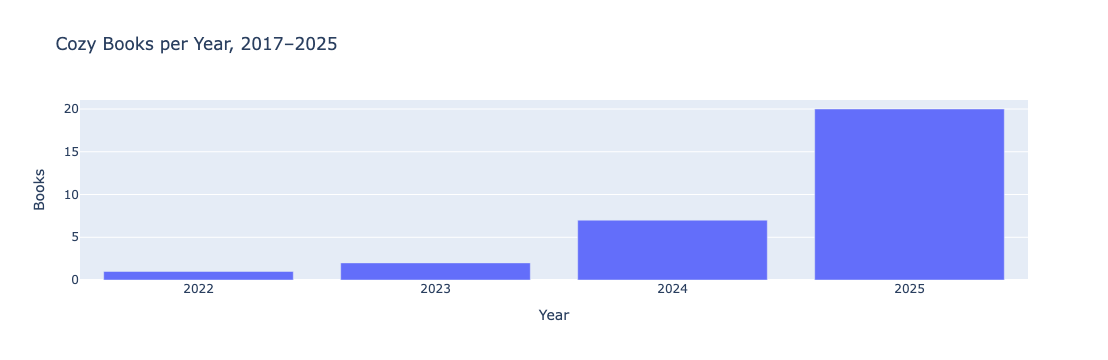

In [6]:
# --- Chart 4: Cozy trend (2017–2025) ---
cozy = (
    df17[df17['is_cozy'] == True]
    .groupby('year')
    .size()
    .reset_index(name='count')
)

fig4 = px.bar(
    cozy,
    x='year', y='count',
    title='Cozy Books per Year, 2017–2025',
    labels={'year': 'Year', 'count': 'Books'},
)
fig4.update_layout(xaxis=dict(tickmode='linear', dtick=1))
fig4.show()

In [7]:
# --- Summary table ---
summary = pivot[['SF', 'Fantasy', 'Horror', 'YA']].copy()
summary['SF_pct_of_SF_Fantasy'] = (summary['SF'] / (summary['SF'] + summary['Fantasy']) * 100).round(1)
summary.index = summary.index.astype(int)
summary

genre_combined,SF,Fantasy,Horror,YA,SF_pct_of_SF_Fantasy
year,,,,,
2017,218,239,31,82,47.7
2018,211,216,32,65,49.4
2019,221,247,33,61,47.2
2020,180,216,37,45,45.5
2021,97,107,44,78,47.5
2022,225,290,149,178,43.7
2023,106,135,77,96,44.0
2024,213,371,179,196,36.5
2025,192,411,214,185,31.8
